# Assignment Goal

The main objective of this assignment is to design and implement a complete **anomaly-detection pipeline** capable of:

1. **Identifying anomalies** in robot navigation runs.
2. **Explaining how and why** each anomaly occurs, based on the available logs and metrics.
3. Extracting meaningful **configuration values or features** that could later be used to **predict anomalies** before they happen.

In [38]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.ensemble import IsolationForest
import os
import glob
import re
import yaml

In [39]:
# GLOBAL VARIABLES

#directories and paths
DATASET_PATH = "ws25_aia_complete_data"
LOGS_DIR = "logs"
SCENARIO_SEP = "maps-"
LOG_CCI = "component_container_isolated"


#NAMES COLUMNS
TIMESTAMP = 'timestamp'
FRAME = 'frame'
POSITION_X = "position.x"
POSITION_Y = "position.y"
ORIENTATION_YAW = 'orientation.yaw'

#FRAMES
REAL_POSE = 'nav2_turtlebot4_base_link_gt'
ESTIMATED_POSE = 'base_link'

#PATERN_LOG
PATTERN_BR = r"\[(.*?)\]"

#LOCALIZATION ERROR
COUNT_IN_CONSISTENT = 3

In [40]:
def compute_path_length(x: np.ndarray, y: np.ndarray) -> float:
    dx = np.diff(x)
    dy = np.diff(y)
    return float(np.sum(np.sqrt(dx ** 2 + dy ** 2)))

#Objects

# Class with the data of a ros iteration in a scenario
class DataProcessed:
    def __init__(self, scenario, run_n, csv_file):
        #general info
        self.scenario = scenario
        self.run_n = run_n
        
        #csv info
        self.csv_file = csv_file
        if os.path.exists(csv_file):
            self.df = pd.read_csv(
                csv_file,
                comment='#',       
                sep=',',           
                quotechar='"',     
                engine='python'
            )
        else:
            #csv does not exist
            self.csv_file = None
        self.position_error = np.array([])
        self.yaw_error = np.array([])
        
        #logs info
        self.logs = []
        self.failure_run = True
        self.init_t = None
        self.end_t = None

        #scenario info
        self.scenario_info = None
        
        #anomalies info
        self.anomalies = []
        self.unique_anomalies = []

        #IsolationForest navigation score 
        metrics = None
        iso_score = None
        

    def add_log(self, log):
        self.logs.append(log)

        #special logs information about begining and end of a run
        if 'Begin navigating' in log.msg:
            self.init_t = log.time
        if 'Goal succeeded' in log.msg:
            self.failure_run = False
            self.end_t = log.time
        if 'Goal failed' in log.msg:
            self.end_t = log.time

    def load_scenario_config(self, path):
        """
        Load a scenario YAML file and extract structured information.

        Parameters:
            path (str): Path to the YAML config file.

        Returns:
            dict: A dictionary containing the parsed scenario information.
        """
        with open(path, 'r') as f:
            data = yaml.safe_load(f)

        # The root key is 'test_scenario'
        scenario = data.get("test_scenario", {})

        # ---- Extract goal poses ----
        goal_poses_raw = scenario.get("goal_poses", [])
        goal_poses = []
        for g in goal_poses_raw:
            goal_poses.append({
                "x": float(g["position"].get("x", 0.0)),
                "y": float(g["position"].get("y", 0.0)),
                "yaw": float(g["orientation"].get("yaw", 0.0))
            })

        # ---- Extract start pose ----
        start_raw = scenario.get("start_pose", {})
        start_pose = {
            "x": float(start_raw.get("position", {}).get("x", 0.0)),
            "y": float(start_raw.get("position", {}).get("y", 0.0)),
            "yaw": float(start_raw.get("orientation", {}).get("yaw", 0.0))
        }

        # ---- Extract static objects ----
        objects_raw = scenario.get("static_objects", [])
        static_objects = []
        for obj in objects_raw:
            spawn_pose = obj.get("spawn_pose", {})
            position = spawn_pose.get("position", {})
            orientation = spawn_pose.get("orientation", {})
            static_objects.append({
                "name": obj.get("entity_name", ""),
                "model": obj.get("model", ""),
                "x": float(position.get("x", 0.0)),
                "y": float(position.get("y", 0.0)),
                "z": float(position.get("z", 0.0)),
                "yaw": float(orientation.get("yaw", 0.0)),
                "xacro_arguments": obj.get("xacro_arguments", "")
            })

        # ---- Build output structure ----
        scenario_info = {
            "goal_poses": goal_poses,
            "start_pose": start_pose,
            "map_file": scenario.get("map_file", ""),
            "mesh_file": scenario.get("mesh_file", ""),
            "laser_noise_std": float(scenario.get("laserscan_gaussian_noise_std_deviation", 0)),
            "laser_drop_pct": float(scenario.get("laserscan_random_drop_percentage", 0)),
            "static_objects": static_objects
        }

        # Save to the instance
        self.scenario_info = scenario_info
        return scenario_info
    
    # Get Pose error of the scenario (2D) in form of position_error, yaw_error, timestamp
    # given deduced pose info and real pose info
    def calculate_pose_error(self):
        if self.csv_file == None:
            return
        
        deduced_pose = self.df.loc[self.df[FRAME] == ESTIMATED_POSE]
        real_pose = self.df.loc[self.df[FRAME] == REAL_POSE]
        
        #since is 2D just take position.x and y and orientation.z and w.
        deduced_position_x = deduced_pose[POSITION_X].to_numpy()
        deduced_position_y = deduced_pose[POSITION_Y].to_numpy()
        deduced_yaw = deduced_pose[ORIENTATION_YAW].to_numpy()
        deduced_timestamp = deduced_pose[TIMESTAMP].to_numpy()
    
        real_position_x = real_pose[POSITION_X].to_numpy()
        real_position_y = real_pose[POSITION_Y].to_numpy()
        real_yaw = real_pose[ORIENTATION_YAW].to_numpy()
        real_timestamp = real_pose[TIMESTAMP].to_numpy()
        
        #get interpolation of real_pose to timestamp of deduced_pose.
        real_position_x_inter = np.interp(deduced_timestamp, real_timestamp, real_position_x)
        real_position_y_inter = np.interp(deduced_timestamp, real_timestamp, real_position_y)
        real_yaw_inter = np.interp(deduced_timestamp, real_timestamp, real_yaw)
    
        #now it is possible to get the vectoriced error
        dx = deduced_position_x - real_position_x_inter
        dy = deduced_position_y - real_position_y_inter
        position_error = np.sqrt(dx**2 + dy**2)
        self.position_error = np.stack((np.array(position_error), np.array(deduced_timestamp)), axis=1)

        #get yaw error.
        yaw_error = deduced_yaw - real_yaw_inter
        #normalice between [-pi, pi]
        yaw_error = (yaw_error + np.pi) % (2 * np.pi) - np.pi
        self.yaw_error = np.stack((yaw_error, deduced_timestamp), axis=1)

    def get_metrics(self):
        if self.csv_file == None or self.end_t == None or self.init_t == None:
            return
        
        #Get basic metrics:
        pos_err = self.position_error[:, 0]
        yaw_err = self.yaw_error[:, 0]
        mean_pos = float(np.nanmean(pos_err))
        rmse_pos = float(np.sqrt(np.nanmean(pos_err ** 2)))
        max_pos = float(np.nanmax(pos_err))
        mae_yaw = float(np.nanmean(np.abs(yaw_err)))

        real_pose = self.df.loc[self.df[FRAME] == REAL_POSE]
        gt_x = real_pose[POSITION_X].to_numpy()
        gt_y = real_pose[POSITION_Y].to_numpy()
        executed_len = compute_path_length(gt_x, gt_y) 

        time_spent = self.end_t - self.init_t
        
        metrics = {
            'mean_pos_error': mean_pos,
            'rmse_pos': rmse_pos,
            'max_pos_error': max_pos,
            'mae_yaw': mae_yaw,
            'executed_path_length': executed_len,
            'time_spent': time_spent
        }
        self.metrics = metrics
        return metrics


    def detect_log_anomalies(self):

        anomalies = []

        for log in self.logs:
    
            # No progress anomaly
            if "Failed to make progress" in log.msg:
                anomalies.append(("no_progress", log.time))
    
            # Planner failure
            if "Failed to create a plan" in log.msg:
                anomalies.append(("planner_failure", log.time))
    
            # Collision
            if "Collision Ahead" in log.msg:
                anomalies.append(("collision", log.time))
    
            # Stuck anomalies
            if "spin failed" in log.msg or "backup failed" in log.msg:
                anomalies.append(("stuck", log.time))
    
            # Fatal initialization
            if log.type == "FATAL":
                anomalies.append(("fatal_initialization", log.time))

            # Goal failed
            if "Goal failed" in log.msg:
                anomalies.append(("goal_failure", log.time))

        if len(self.logs) == 0:
            anomalies.append(("no_initiation", 0))

        
        self.anomalies += anomalies

    def detect_time_anomalie(self, scenario_data):
        time_run = []
        
        for data in scenario_data:
            if data.init_t is not None and data.end_t is not None:
                time_run.append(data.end_t - data.init_t)

        #since we know the number of runs is low, we use median instead of mean which also is not influenced by outliers
        if len(time_run) != 0:
            med = np.median(time_run)
            MAD = np.median(np.abs(time_run - med))  # Median of absolute desviation

            # tipic threshold: 3 * MAD
            umbral = med + 3 * MAD
            if self.init_t is not None and self.end_t is not None:
                if self.end_t - self.init_t > umbral:
                    self.anomalies.append(("time_outlier", self.end_t))
    
    def detect_localization_anomalie(self, umbral_error):
        if self.csv_file == None:
            return

        anomalies = []
        in_outlier = False
        count_in = 0

        position_sorted = self.position_error[self.position_error[:, 1].argsort()]
        # if the error is higher than the umbral error and is consisten which it means
        # there is more than one measure outside the error, it is detected the anomalie
        for p_err, t in position_sorted:
            if p_err > umbral_error:
                if not in_outlier:
                    in_outlier = True
                else:
                    if count_in == COUNT_IN_CONSISTENT:
                        anomalies.append(("position_error", t)) 
                count_in = count_in + 1
            elif p_err < umbral_error and in_outlier:
                in_outlier = False
                count_in = 0
                
        self.anomalies += anomalies
    
    def detect_navigation_performance(self, iso_tree):
        #score using the tree
        if self.csv_file == None or self.init_t is None or self.end_t is None:
            return

        summary = pd.DataFrame([self.metrics])

        num_cols = ['mean_pos_error', 'rmse_pos', 'max_pos_error', 'mae_yaw', 'executed_path_length', 'time_spent']
        feat_df = summary[num_cols].fillna(-1)
        try:   
            score = iso.decision_function(feat_df)
            self.iso_score = score[0]
            anom = iso.predict(feat_df)
            if anom[0] == -1:
                self.anomalies.append(("navigation_performance", self.end_t))
        except Exception as e:
            print('IsolationForest failed:', e)

    def clean_anomalies(self):
        self.anomalies = []

    def get_unique_anomalies(self):
        if len(self.anomalies) != 0:
            self.unique_anomalies = set(a[0] for a in self.anomalies)
        return self.unique_anomalies
        
#Class for the logs of ros
class LogsRos:
    def __init__(self, type_msg, time, sender, msg):
        self.type = type_msg
        self.time = time
        self.sender = sender
        self.msg = msg

cmap = plt.get_cmap('tab10')

# Scenario Data Overview

In our analysis pipeline, the main sources of information are the robot's **poses.csv** and **log files**, while the scenario configuration file serves as reference for future use.

## Main Data Sources

1. **Poses.csv**
   - Contains timestamped robot positions.
   - Used to compute **localization errors** by comparing:
     - `nav2_turtlebot4_base_link_gt` (ground truth)
     - `base_link` (estimated pose)
   - Helps detect anomalies related to navigation and localization performance.

2. **Log Files**
   - Record robot actions, system messages, and events.
   - Used to detect different **types of anomalies** during runs, such as:
     - Collisions
     - Stuck situations
     - Planner failures
     - Goal failures
   - Critical for identifying runs that fail or behave abnormally.

## Scenario Configuration File

- Contains information such as:
  - Start and goal poses
  - Map and mesh files
  - Laser sensor parameters
  - Static objects in the environment
- While not directly analyzed for anomaly detection, it is **stored and examined** to provide context and could be used as input features in future predictive models.

## Purpose

- **poses.csv** and **logs** → primary sources for detecting and analyzing anomalies.
- **Configuration file** → reference for scenario setup, potential input for predictive models.


In [41]:
#Get data stored and preprocessing
dataset = []

for scenario_dir in os.listdir(DATASET_PATH):
    # Skip hidden files like .DS_Store
    if scenario_dir.startswith('.'):
        continue
    scenario_path = os.path.join(DATASET_PATH, scenario_dir)
    # Skip if not a directory
    if not os.path.isdir(scenario_path):
        continue
    scenario = scenario_dir.split(SCENARIO_SEP)[1]
    scenario_group = []
    for run_n in os.listdir(scenario_path):
        # Skip hidden files and non-directories
        if run_n.startswith('.'):
            continue
        run_path = os.path.join(scenario_path, run_n)
        if not os.path.isdir(run_path):
            continue
        #get csv
        csv_file = os.path.join(scenario_path, run_n, "poses.csv")
        data = DataProcessed(scenario, int(run_n), csv_file)
        data.calculate_pose_error()
        #get scenario info
        scnario_info_file = os.path.join(scenario_path, run_n, "scenario.config")
        #get logs
        logs_file = glob.glob(scenario_path + "/" + run_n + "/" + LOGS_DIR + "/" + LOG_CCI + "*")
        if len(logs_file) != 0 and os.path.isfile(logs_file[0]):
            with open(logs_file[0], "r") as f:
                for line in f:
                    # get strings between []
                    brakets = re.findall(PATTERN_BR, line)
                    if len(brakets) == 3:
                        # log info are structured like [type] [time] [sender] : msg
                        type_msg = brakets[0]
                        time = float(brakets[1])
                        sender = brakets[2]
                        msg = line.split("]:")[-1].strip()
                        log = LogsRos(type_msg, time, sender, msg)
                        #Add log to the datasetRos object
                        data.add_log(log)
                        
        scenario_group.append(data)
    dataset.append(scenario_group)

## Detectable Anomalies

The system is able to detect several types of anomalies based on the logs and run-level metrics. These anomalies fall into both logic-based and statistical categories:

---

#### **1. No Initiation**
The system fails to start correctly.  
This anomaly is detected when essential log messages are missing, meaning the robot never properly initialized.

#### **2. Fatal Initiation**
A critical error occurs during startup, preventing the robot from initiating the run.  
This typically happens when the initialization sequence encounters an unrecoverable failure.

---

#### **3. Planner Failure**
The motion planner is unable to generate a valid trajectory to the goal.  
This usually indicates map inconsistencies, invalid robot state, or unreachable target configurations.

#### **4. No Progress**
Although the robot moves, it does not make meaningful progress toward the goal.  
This is detected through repeated position updates showing negligible forward displacement.

#### **5. Collision (Near-Collision Warning)**
The system detects that the robot approaches extremely close to an obstacle.  
It does not necessarily confirm physical contact, but signals dangerously small distances that indicate imminent collision risk.

#### **6. Stuck**
The robot attempts to move—often reversing or spinning in place—but consistently fails to change its position because it is physically stuck.

#### **7. Goal Failure**
The robot fails to reach the goal within operational constraints (time, progress, or valid path availability).

---

### Temporal Anomaly (Time Outlier)
This anomaly is detected by comparing the run duration with other runs from the same scenario.  
Because the number of runs per scenario is small, the threshold is computed using the **median** rather than the mean.  
Runs that take significantly longer than the median are flagged as temporal anomalies.

---

### Localization Error Anomaly
With more available data, localization error is analyzed statistically:

- The **mean** and **standard deviation** (std) of the localization error are computed across all runs.
- An anomaly is flagged when  
  **error > mean + 3 × std**

To avoid detecting short, noisy spikes, an anomaly is only confirmed when the error remains above this threshold for **three consecutive measurements**, ensuring that only consistent outliers are marked.

---

These combined anomaly detectors allow the system to capture both hard failures (e.g., no initiation, fatal initiation) and soft or emerging issues (e.g., time outlier, elevated localization noise), improving overall diagnostic coverage.

## Navigation Performance Evaluation Using Isolation Forest

To assess the navigation performance of each run, we use an **Isolation Forest** model, a tree-based anomaly detection algorithm. The idea is to identify runs whose metrics deviate significantly from the norm.  

**How it works:**

1. **Input Features:** For each run, we collect numeric navigation metrics such as:
   - Mean and RMSE of position error
   - Maximum position error
   - Yaw error
   - Executed path length
   - Time spent  

2. **Training the Isolation Forest:**  
   The model is trained on these metrics across multiple runs. The Isolation Forest isolates outliers by recursively partitioning the data: runs that are “easier to isolate” are considered more anomalous.

3. **Scoring a Run:**  
   Once trained, the model assigns an **anomaly score** to a run. A negative prediction (`-1`) indicates an anomaly in navigation performance, while `1` indicates normal behavior.

4. **Decision:**  
   If a run is predicted as an outlier by the Isolation Forest, it is flagged as a **navigation performance anomaly** and added to the run’s list of detected anomalies. This allows us to capture runs that, even if they complete successfully, exhibit unusual behavior compared to the majority.



umbral_position_error:  0.877198388027938


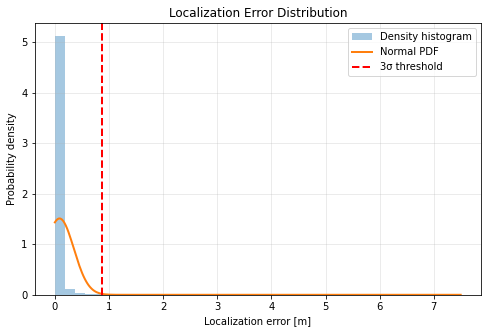

In [ ]:

position_error_total = []
metrics_total = []

for scenario_group in dataset:
    for data in scenario_group: 
        if data.csv_file is not None:
            position_error_total.extend(data.position_error[:,0])
            metrics = data.get_metrics()
            if metrics is not None:
                metrics_total.append(metrics)

#Get mean of localization error and variance to determine when the localization error is anomaly big
position_error_total = np.array(position_error_total)
mean = position_error_total.mean()
std = position_error_total.std()
umbral_position_error = mean + 3 * std
print( "umbral_position_error: " , umbral_position_error)

# PDF curve
x = np.linspace(0, position_error_total.max(), 300)
pdf = norm.pdf(x, mean, std)

plt.figure(figsize=(8,5))

# Density histogram
plt.hist(position_error_total, bins=40, density=True, alpha=0.4, label="Density histogram")

# PDF curve
plt.plot(x, pdf, linewidth=2, label="Normal PDF")

# Threshold line
plt.axvline(umbral_position_error, color='r', linestyle="--", linewidth=2, label="3σ threshold")

plt.xlabel("Localization error [m]")
plt.ylabel("Probability density")
plt.title("Localization Error Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('images/Localization_Error_Distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#Calculate navigation performance training the isolation tree
summary = pd.DataFrame(metrics_total)

num_cols = ['mean_pos_error', 'rmse_pos', 'max_pos_error', 'mae_yaw', 'executed_path_length', 'time_spent']
feat_df = summary[num_cols].fillna(-1)
if len(feat_df) > 0 and feat_df.shape[0] >= 3:
    iso = IsolationForest(random_state=42, contamination=0.1)
    try:
        iso.fit(feat_df)
    except Exception as e:
        print('IsolationForest failed:', e)


In [43]:
#Get Anomalies
all_anomalies = []
all_anomalies_f_run = []
unique_anomalies = []
unique_anomalies_f_run = []


for scenario_group in dataset:
    for data in scenario_group: 
        data.clean_anomalies()
        data.detect_log_anomalies()
        data.detect_time_anomalie(scenario_group)
        data.detect_localization_anomalie(umbral_position_error)
        data.detect_navigation_performance(iso)

        unique_a = data.get_unique_anomalies()
        unique_anomalies.extend(unique_a)
        all_anomalies.extend(data.anomalies)
        if data.failure_run:
            all_anomalies_f_run.extend(data.anomalies)
            unique_anomalies_f_run.extend(unique_a)



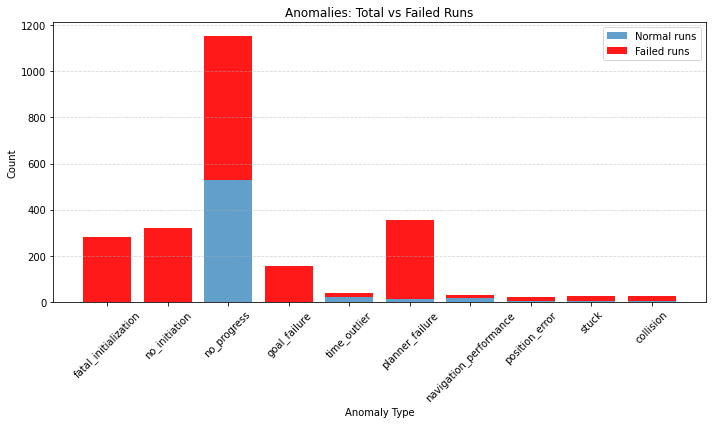

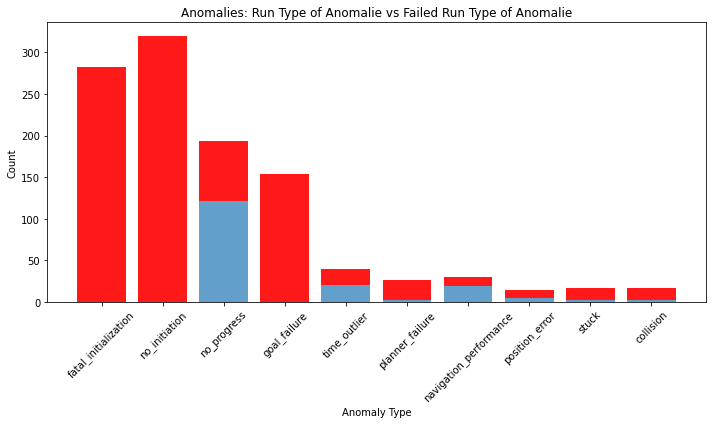

In [ ]:
#Analyse anomalies
 
# Flatten lists
flattened_all = [a[0] for a in all_anomalies]
flattened_fail = [a[0] for a in all_anomalies_f_run]

# Count occurrences
count_all = Counter(flattened_all)
count_fail = Counter(flattened_fail)
count_uall = Counter(unique_anomalies)
count_ufail = Counter(unique_anomalies_f_run)

#Total Count of anomalies in the data set and which of this anomalies are asociated with a failed run
anomaly_types = list(count_all.keys())
total_counts = np.array([count_all[t] for t in anomaly_types])
fail_counts = np.array([count_fail.get(t, 0) for t in anomaly_types])
normal_counts = total_counts - fail_counts

# Plot stacked bar chart
plt.figure(figsize=(10,6))
plt.bar(anomaly_types, normal_counts, label="Normal runs", alpha=0.7)
plt.bar(anomaly_types, fail_counts, bottom=normal_counts, label="Failed runs", alpha=0.9, color='r')
    
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.title("Anomalies: Total vs Failed Runs")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('images/Anomalies_Total_vs_Failed_Runs.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Unique anomalies count per run in the data set and which of this anomalies are asociated with a failed run
anomaly_types = list(count_uall.keys())
total_counts = np.array([count_uall[t] for t in anomaly_types])
fail_counts = np.array([count_ufail.get(t, 0) for t in anomaly_types])
normal_counts = total_counts - fail_counts

# Plot stacked bar chart
plt.figure(figsize=(10,6))
plt.bar(anomaly_types, normal_counts, label="Normal runs", alpha=0.7)
plt.bar(anomaly_types, fail_counts, bottom=normal_counts, label="Failed runs", alpha=0.9, color='r')
    
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.title("Anomalies: Run Type of Anomalie vs Failed Run Type of Anomalie")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/Anomalies_Run_Type_vs_Failed.png', dpi=150, bbox_inches='tight', facecolor='white')

plt.show()
plt.show()


### Interpretation of Anomaly Count Plots

In the **first plot**, we see the **total count of each anomaly type** across the entire dataset and across all runs.  
In the **second plot**, we visualize **how many runs** experienced each anomaly type at least once.

By comparing both, we can identify important patterns:

- **No initiation** and **fatal initiation** anomalies have **low total counts**, yet they occur in a **large number of runs**.  
  → This means they don’t accumulate many times within a run, but when they appear, they *almost always* cause the run to fail.

- **Planner failure** and **no progress** anomalies show the opposite behavior:  
  → They have **high total counts**, but they occur in **fewer runs overall**.  
  This indicates that these anomalies tend to **accumulate heavily within the same runs**.

- Among these, **no progress** is the anomaly **least associated with run failure**, followed by **navigation performance** and **time outlier**.

- On the other hand, **no initiation** and **fatal initiation** are almost guaranteed indicators of run failure.

Overall, the comparison reveals which anomalies are “fatal” single events versus those that accumulate but do not always cause a complete run failure.



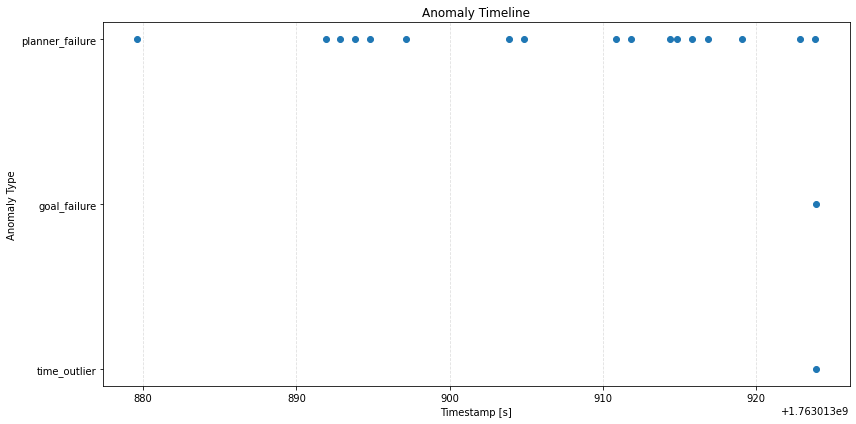

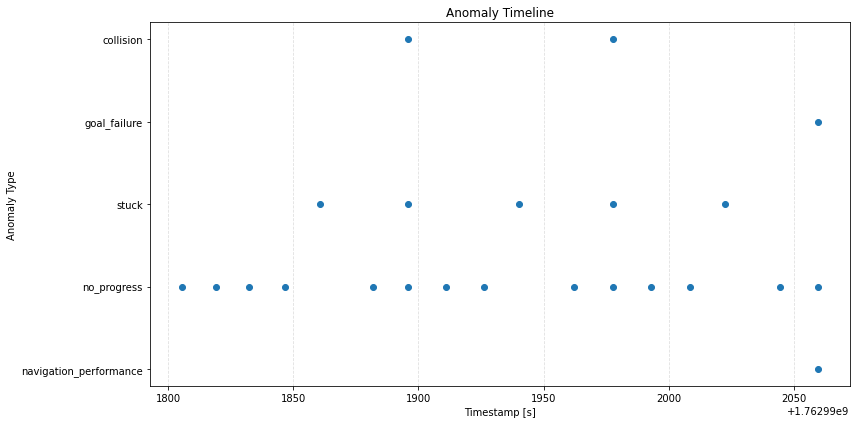

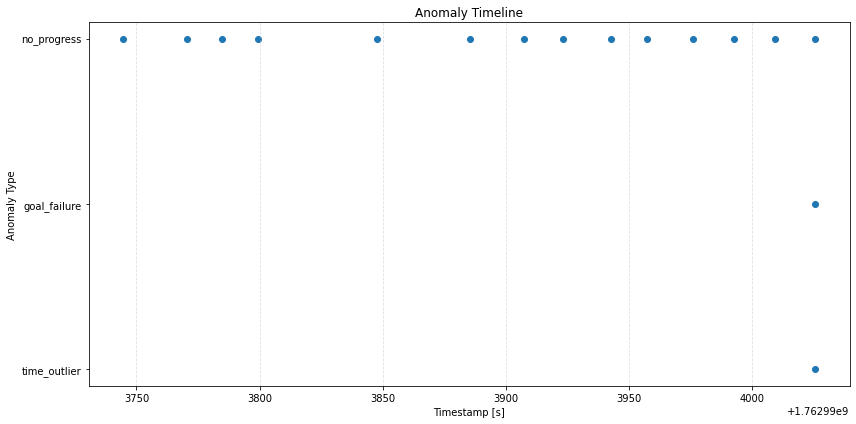

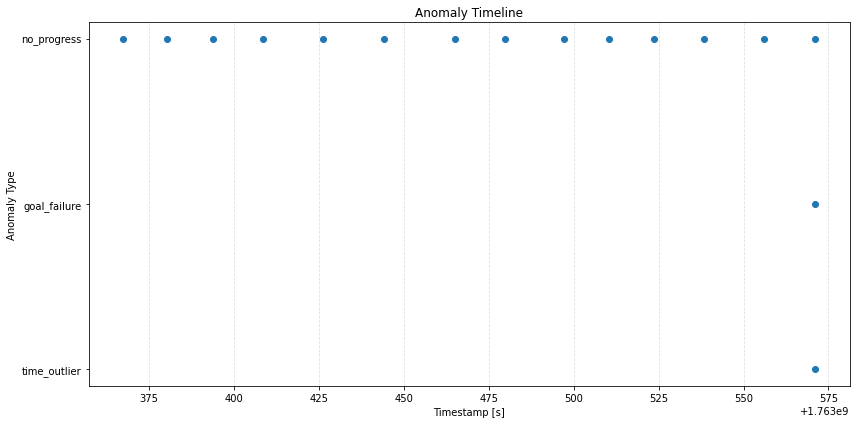

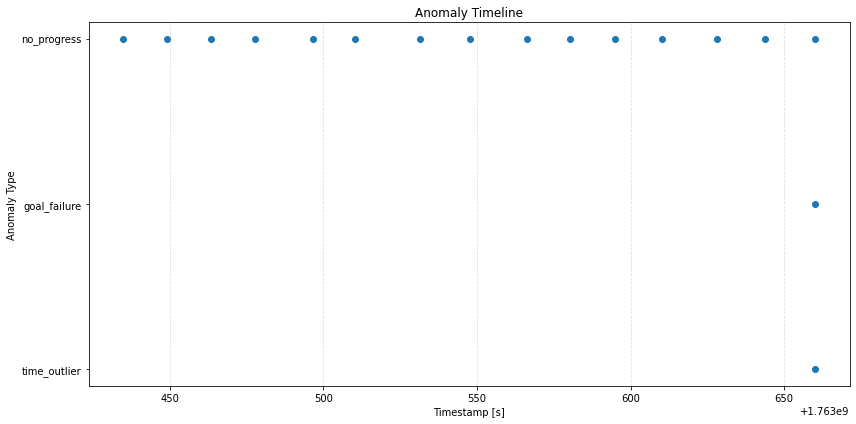

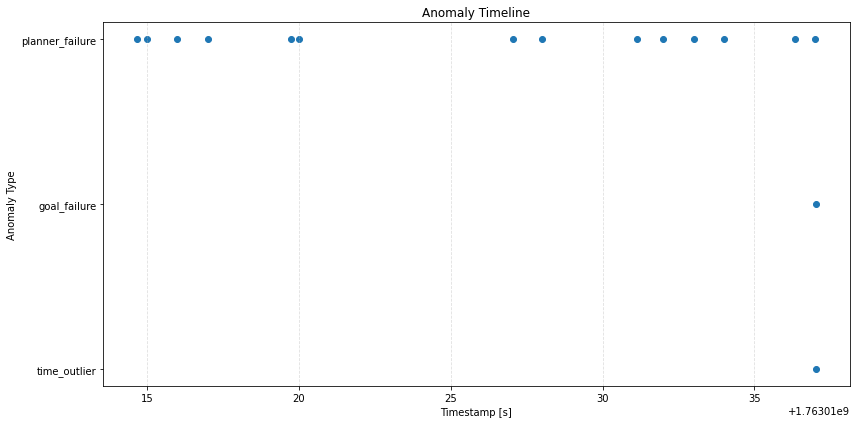

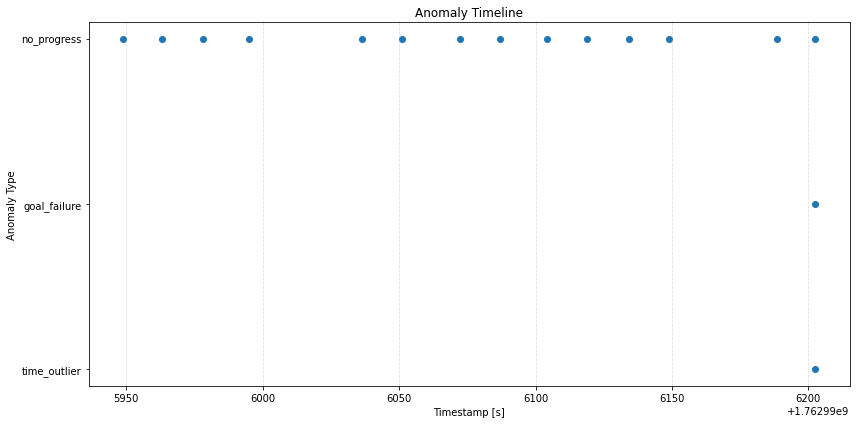

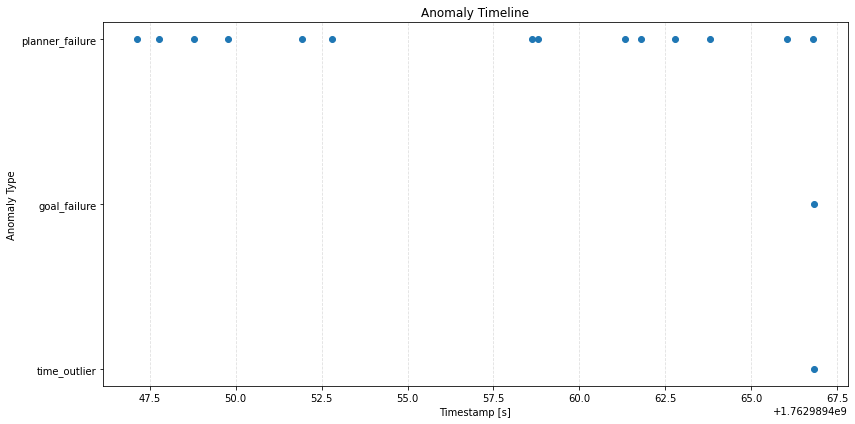

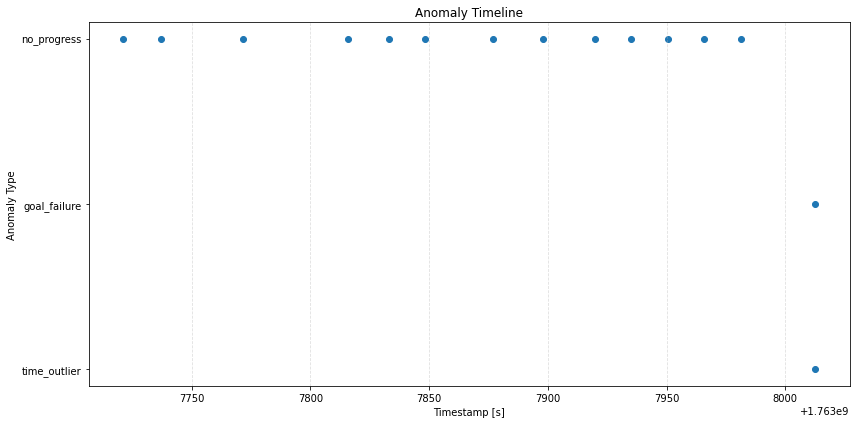

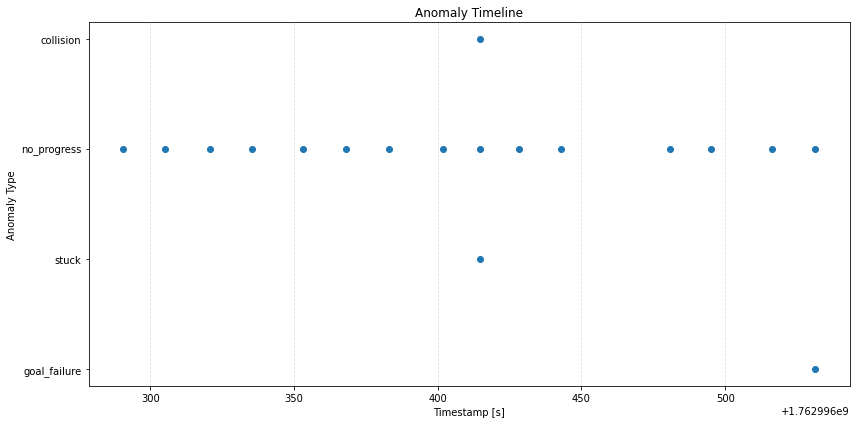

In [ ]:
def plot_anomaly_timeline(flattened_anomalies, save_path=None):
    """
    flattened_anomalies: list of (anomaly_type, timestamp)
    Example: [("COLLISION", 12.5), ("FOLLOW_FAIL", 88.1)]
    """

    if len(flattened_anomalies) == 0:
        print("No anomalies to plot.")
        return

    # Sort by timestamp
    flattened_anomalies = sorted(flattened_anomalies, key=lambda x: x[1])

    # Extract unique types and assign y-levels
    anomaly_types = list(set(a[0] for a in flattened_anomalies))
    type_to_y = {atype: i for i, atype in enumerate(anomaly_types)}

    # Prepare X (time) & Y (anomaly type levels)
    x_vals = [a[1] for a in flattened_anomalies]
    y_vals = [type_to_y[a[0]] for a in flattened_anomalies]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.scatter(x_vals, y_vals)

    plt.yticks(list(type_to_y.values()), list(type_to_y.keys()))
    plt.xlabel("Timestamp [s]")
    plt.ylabel("Anomaly Type")
    plt.title("Anomaly Timeline")
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

#Shows the most interesting runs in time to identify correlation between anomalies
timeline_count = 0
for scenario_group in dataset:
    for data in scenario_group: 
        if len(data.anomalies) >= 15 and len(data.unique_anomalies) >= 3:
            timeline_count += 1
            plot_anomaly_timeline(data.anomalies, f'images/Anomaly_Timeline_{timeline_count}.png')

## Analysis of Anomaly Relationships

From these plots, we can observe several clear relationships between the different anomaly types:

- **Collision anomalies** are strongly correlated with the robot becoming **stuck** afterward.  
- Being stuck is also linked to the robot **failing to make progress**, suggesting a causal chain between these events.
- It appears that, in most cases, **either** a “no progress” anomaly **or** a “failed to generate a path to the goal” anomaly occurs — often one or the other dominates.
- In scenarios where many instances of either of these two anomalies accumulate, the run tends to take **significantly longer than normal**, eventually causing the robot to **give up before reaching the goal**.

Overall, these relationships indicate that certain anomaly types reinforce each other, forming failure patterns that can degrade performance or lead to complete run failure.

## Correlation Analysis: Metrics vs Anomalies

To understand which metrics or combination of metrics best predict specific anomalies, we compute correlations between navigation metrics and anomaly occurrences. This helps identify:

1. **Single-source predictors**: Metrics that independently correlate with specific anomalies
2. **Multi-source predictors**: Combinations of metrics that together indicate anomalies

This analysis supports both rule-based and learning-based anomaly detection approaches.

In [47]:

# CORRELATION ANALYSIS: METRICS VS ANOMALIES

from scipy.stats import pointbiserialr
import seaborn as sns

def build_analysis_dataframe(dataset):
    """Build a DataFrame with metrics and anomaly labels for correlation analysis."""
    records = []
    
    for scenario_group in dataset:
        for data in scenario_group:
            if data.csv_file is None or data.init_t is None or data.end_t is None:
                continue
            
            metrics = data.metrics if hasattr(data, 'metrics') and data.metrics else {}
            if not metrics:
                continue
                
            unique_anoms = data.get_unique_anomalies()
            
            record = {
                'scenario': data.scenario,
                'run': data.run_n,
                'mean_pos_error': metrics.get('mean_pos_error', np.nan),
                'rmse_pos': metrics.get('rmse_pos', np.nan),
                'max_pos_error': metrics.get('max_pos_error', np.nan),
                'mae_yaw': metrics.get('mae_yaw', np.nan),
                'executed_path_length': metrics.get('executed_path_length', np.nan),
                'time_spent': metrics.get('time_spent', np.nan),
                'failure_run': int(data.failure_run),
                'num_anomalies': len(data.anomalies),
                # Binary anomaly indicators
                'has_collision': int('collision' in unique_anoms),
                'has_stuck': int('stuck' in unique_anoms),
                'has_no_progress': int('no_progress' in unique_anoms),
                'has_planner_failure': int('planner_failure' in unique_anoms),
                'has_position_error': int('position_error' in unique_anoms),
                'has_time_outlier': int('time_outlier' in unique_anoms),
                'has_goal_failure': int('goal_failure' in unique_anoms),
            }
            records.append(record)
    
    return pd.DataFrame(records)

analysis_df = build_analysis_dataframe(dataset)
print(f"Analysis DataFrame shape: {analysis_df.shape}")
print(f"\nRun outcome distribution:")
print(f"  Successful runs: {(analysis_df['failure_run'] == 0).sum()}")
print(f"  Failed runs: {(analysis_df['failure_run'] == 1).sum()}")

# Display summary statistics
print("\n" + "=" * 60)
print("METRIC STATISTICS")
print("=" * 60)
metric_cols = ['mean_pos_error', 'rmse_pos', 'max_pos_error', 'mae_yaw', 'executed_path_length', 'time_spent']
print(analysis_df[metric_cols].describe().round(4).to_string())

Analysis DataFrame shape: (296, 17)

Run outcome distribution:
  Successful runs: 142
  Failed runs: 154

METRIC STATISTICS
       mean_pos_error  rmse_pos  max_pos_error   mae_yaw  executed_path_length  time_spent
count        296.0000  296.0000       296.0000  296.0000              296.0000    296.0000
mean           0.0982    0.1215         0.2634    0.0613               14.8547    143.4327
std            0.2512    0.3371         0.6173    0.2097               11.5484     91.8650
min            0.0097    0.0120         0.0263    0.0090                0.3139     19.1845
25%            0.0432    0.0485         0.1015    0.0226                5.1533     54.7231
50%            0.0575    0.0646         0.1357    0.0268               13.7474    140.4703
75%            0.0735    0.0809         0.1862    0.0329               21.9538    212.6968
max            3.4680    4.6857         7.4969    2.2172               51.6834    347.0506


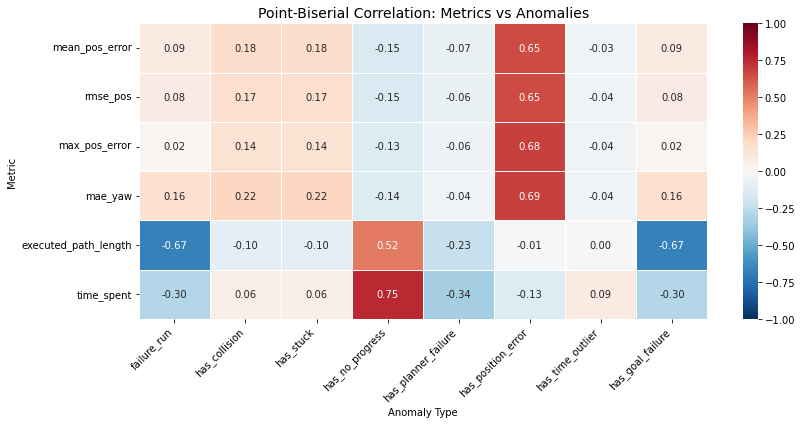


Key Observations:
------------------------------------------------------------
  failure_run: strongest correlation with 'executed_path_length' (r=-0.672)
  has_collision: strongest correlation with 'mae_yaw' (r=0.216)
  has_stuck: strongest correlation with 'mae_yaw' (r=0.216)
  has_no_progress: strongest correlation with 'time_spent' (r=0.752)
  has_planner_failure: strongest correlation with 'time_spent' (r=-0.337)
  has_position_error: strongest correlation with 'mae_yaw' (r=0.687)
  has_goal_failure: strongest correlation with 'executed_path_length' (r=-0.672)


In [ ]:

# CORRELATION HEATMAP: METRICS VS ANOMALIES

# Compute point-biserial correlation between continuous metrics and binary anomaly labels
metric_cols = ['mean_pos_error', 'rmse_pos', 'max_pos_error', 'mae_yaw', 'executed_path_length', 'time_spent']
anomaly_cols = ['failure_run', 'has_collision', 'has_stuck', 'has_no_progress', 
                'has_planner_failure', 'has_position_error', 'has_time_outlier', 'has_goal_failure']

# Build correlation matrix
corr_matrix = np.zeros((len(metric_cols), len(anomaly_cols)))

for i, metric in enumerate(metric_cols):
    for j, anomaly in enumerate(anomaly_cols):
        valid_mask = ~np.isnan(analysis_df[metric])
        if valid_mask.sum() > 2:
            corr, _ = pointbiserialr(analysis_df.loc[valid_mask, anomaly], 
                                      analysis_df.loc[valid_mask, metric])
            corr_matrix[i, j] = corr if not np.isnan(corr) else 0

corr_df = pd.DataFrame(corr_matrix, index=metric_cols, columns=anomaly_cols)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Point-Biserial Correlation: Metrics vs Anomalies', fontsize=14)
plt.xlabel('Anomaly Type')
plt.ylabel('Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/correlation_metrics_anomalies.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nKey Observations:")
print("-" * 60)
# Find strongest correlations
for anomaly in anomaly_cols:
    max_corr_idx = np.abs(corr_df[anomaly]).idxmax()
    max_corr_val = corr_df.loc[max_corr_idx, anomaly]
    if abs(max_corr_val) > 0.2:
        print(f"  {anomaly}: strongest correlation with '{max_corr_idx}' (r={max_corr_val:.3f})")

## Early Prediction Analysis

To enable **early prediction of anomalies**, we analyze patterns in sensor data and metrics at different stages of a run. The key idea is to identify warning signals that appear **before** a critical anomaly occurs.

### Approach:
1. **Temporal segmentation**: Divide each run into early (first 30%), middle (30-70%), and late (70-100%) phases
2. **Feature extraction**: Compute metrics for each phase separately  
3. **Pattern identification**: Find features in early phases that correlate with later anomalies

In [49]:

# EARLY PREDICTION: TEMPORAL FEATURE ANALYSIS

def compute_temporal_features(data):
    """
    Compute features from early, middle, and late phases of a run.
    Returns dict with phase-specific metrics for early anomaly prediction.
    """
    if data.csv_file is None or len(data.position_error) == 0:
        return None
    
    pos_err = data.position_error
    timestamps = pos_err[:, 1]
    errors = pos_err[:, 0]
    
    if len(timestamps) < 10:
        return None
    
    # Define phase boundaries (30%, 70%)
    t_min, t_max = timestamps.min(), timestamps.max()
    t_range = t_max - t_min
    t_early = t_min + 0.3 * t_range
    t_late = t_min + 0.7 * t_range
    
    # Split into phases
    early_mask = timestamps <= t_early
    middle_mask = (timestamps > t_early) & (timestamps <= t_late)
    late_mask = timestamps > t_late
    
    features = {
        'early_mean_error': np.nanmean(errors[early_mask]) if early_mask.sum() > 0 else np.nan,
        'early_max_error': np.nanmax(errors[early_mask]) if early_mask.sum() > 0 else np.nan,
        'early_std_error': np.nanstd(errors[early_mask]) if early_mask.sum() > 0 else np.nan,
        'middle_mean_error': np.nanmean(errors[middle_mask]) if middle_mask.sum() > 0 else np.nan,
        'late_mean_error': np.nanmean(errors[late_mask]) if late_mask.sum() > 0 else np.nan,
        'error_trend': (np.nanmean(errors[late_mask]) - np.nanmean(errors[early_mask])) 
                       if (early_mask.sum() > 0 and late_mask.sum() > 0) else np.nan,
    }
    
    # Count early anomalies (first 30% of run time)
    if data.init_t is not None and data.end_t is not None:
        run_duration = data.end_t - data.init_t
        early_time_threshold = data.init_t + 0.3 * run_duration
        early_anomaly_count = sum(1 for a in data.anomalies if a[1] < early_time_threshold)
        features['early_anomaly_count'] = early_anomaly_count
    else:
        features['early_anomaly_count'] = 0
    
    features['failure_run'] = int(data.failure_run)
    features['total_anomalies'] = len(data.anomalies)
    
    return features

# Build temporal features dataframe
temporal_records = []
for scenario_group in dataset:
    for data in scenario_group:
        feats = compute_temporal_features(data)
        if feats is not None:
            feats['scenario'] = data.scenario
            feats['run'] = data.run_n
            temporal_records.append(feats)

temporal_df = pd.DataFrame(temporal_records)
print(f"Temporal analysis DataFrame shape: {temporal_df.shape}")

Temporal analysis DataFrame shape: (300, 11)


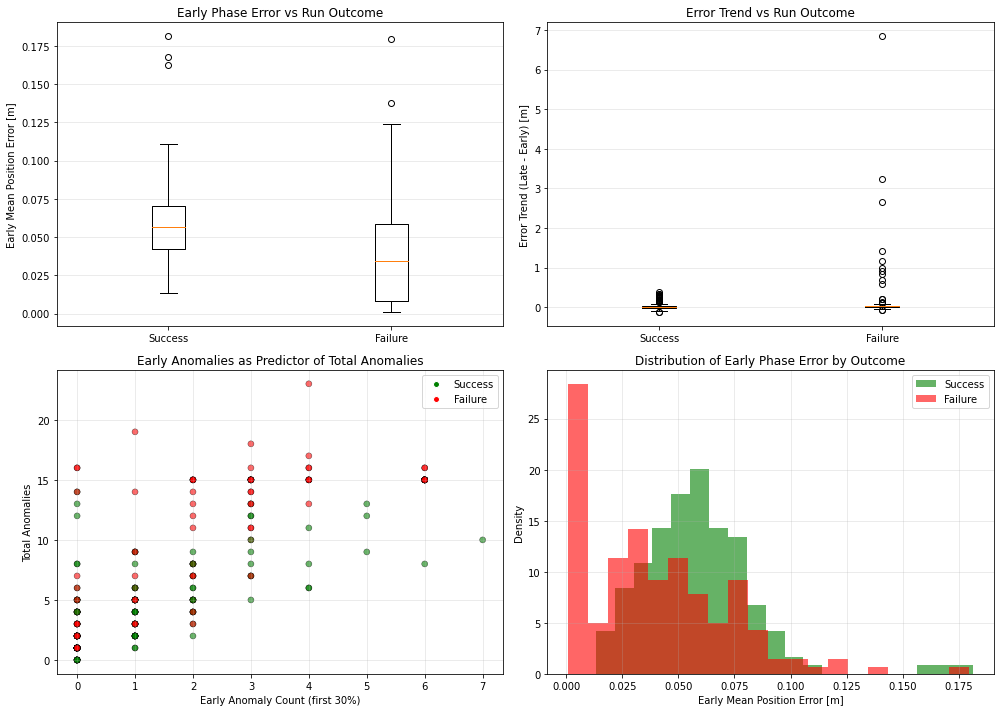


EARLY PREDICTION INDICATORS

Early Mean Error:
  Successful runs: 0.0585 ± 0.0260 m
  Failed runs: 0.0398 ± 0.0324 m
  Mann-Whitney U test p-value: 0.0000
  → Significant difference: Early error is a valid predictor!


In [ ]:

# EARLY WARNING INDICATORS VISUALIZATION

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Early mean error vs failure
ax1 = axes[0, 0]
success_early = temporal_df[temporal_df['failure_run'] == 0]['early_mean_error'].dropna()
failure_early = temporal_df[temporal_df['failure_run'] == 1]['early_mean_error'].dropna()
ax1.boxplot([success_early, failure_early], labels=['Success', 'Failure'])
ax1.set_ylabel('Early Mean Position Error [m]')
ax1.set_title('Early Phase Error vs Run Outcome')
ax1.grid(axis='y', alpha=0.3)

# 2. Error trend (late - early) vs failure
ax2 = axes[0, 1]
success_trend = temporal_df[temporal_df['failure_run'] == 0]['error_trend'].dropna()
failure_trend = temporal_df[temporal_df['failure_run'] == 1]['error_trend'].dropna()
ax2.boxplot([success_trend, failure_trend], labels=['Success', 'Failure'])
ax2.set_ylabel('Error Trend (Late - Early) [m]')
ax2.set_title('Error Trend vs Run Outcome')
ax2.grid(axis='y', alpha=0.3)

# 3. Early anomaly count vs total anomalies
ax3 = axes[1, 0]
colors = ['green' if f == 0 else 'red' for f in temporal_df['failure_run']]
ax3.scatter(temporal_df['early_anomaly_count'], temporal_df['total_anomalies'], 
            c=colors, alpha=0.6, edgecolors='k', linewidth=0.5)
ax3.set_xlabel('Early Anomaly Count (first 30%)')
ax3.set_ylabel('Total Anomalies')
ax3.set_title('Early Anomalies as Predictor of Total Anomalies')
ax3.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Success'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Failure')])
ax3.grid(alpha=0.3)

# 4. Early std error distribution
ax4 = axes[1, 1]
ax4.hist(success_early, bins=20, alpha=0.6, label='Success', color='green', density=True)
ax4.hist(failure_early, bins=20, alpha=0.6, label='Failure', color='red', density=True)
ax4.set_xlabel('Early Mean Position Error [m]')
ax4.set_ylabel('Density')
ax4.set_title('Distribution of Early Phase Error by Outcome')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/early_prediction_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Statistical summary
print("\n" + "=" * 60)
print("EARLY PREDICTION INDICATORS")
print("=" * 60)
print(f"\nEarly Mean Error:")
print(f"  Successful runs: {success_early.mean():.4f} ± {success_early.std():.4f} m")
print(f"  Failed runs: {failure_early.mean():.4f} ± {failure_early.std():.4f} m")

if len(success_early) > 0 and len(failure_early) > 0:
    from scipy.stats import mannwhitneyu
    stat, p_val = mannwhitneyu(success_early, failure_early, alternative='two-sided')
    print(f"  Mann-Whitney U test p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("  → Significant difference: Early error is a valid predictor!")

## Anomaly Co-occurrence Analysis

To understand which anomalies tend to occur together, we compute co-occurrence patterns. This reveals causal chains and helps identify root causes vs. symptoms.

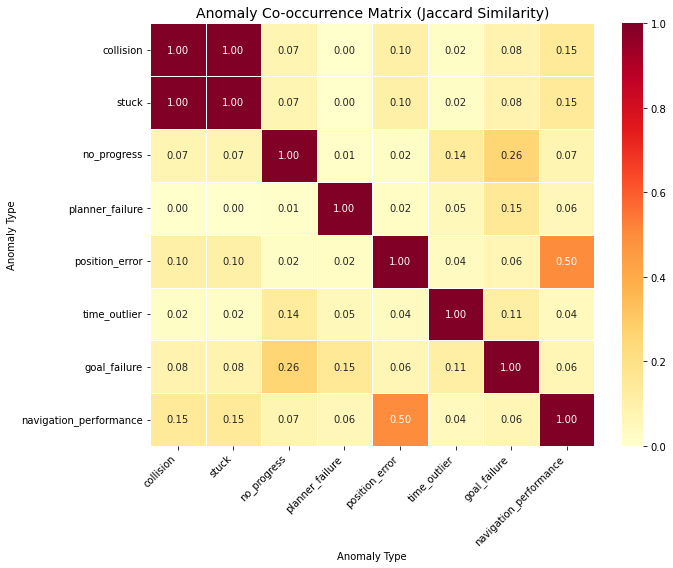


Strong Co-occurrences (Jaccard > 0.3):
--------------------------------------------------
  collision ↔ stuck: 1.00
  position_error ↔ navigation_performance: 0.50


In [ ]:

# ANOMALY CO-OCCURRENCE MATRIX

anomaly_types_list = ['collision', 'stuck', 'no_progress', 'planner_failure', 
                      'position_error', 'time_outlier', 'goal_failure', 'navigation_performance']

# Build co-occurrence matrix
cooccurrence = np.zeros((len(anomaly_types_list), len(anomaly_types_list)))

for scenario_group in dataset:
    for data in scenario_group:
        unique_anoms = data.get_unique_anomalies()
        for i, anom1 in enumerate(anomaly_types_list):
            for j, anom2 in enumerate(anomaly_types_list):
                if anom1 in unique_anoms and anom2 in unique_anoms:
                    cooccurrence[i, j] += 1

# Normalize by diagonal (Jaccard-like)
cooccurrence_norm = cooccurrence.copy()
for i in range(len(anomaly_types_list)):
    for j in range(len(anomaly_types_list)):
        denom = cooccurrence[i, i] + cooccurrence[j, j] - cooccurrence[i, j]
        cooccurrence_norm[i, j] = cooccurrence[i, j] / denom if denom > 0 else 0

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=anomaly_types_list, yticklabels=anomaly_types_list,
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Anomaly Co-occurrence Matrix (Jaccard Similarity)', fontsize=14)
plt.xlabel('Anomaly Type')
plt.ylabel('Anomaly Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/anomaly_cooccurrence.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nStrong Co-occurrences (Jaccard > 0.3):")
print("-" * 50)
for i, anom1 in enumerate(anomaly_types_list):
    for j, anom2 in enumerate(anomaly_types_list):
        if i < j and cooccurrence_norm[i, j] > 0.3:
            print(f"  {anom1} ↔ {anom2}: {cooccurrence_norm[i, j]:.2f}")

## Metrics Distribution by Run Outcome

Visualizing how key metrics differ between successful and failed runs helps identify the most discriminative features for anomaly prediction.

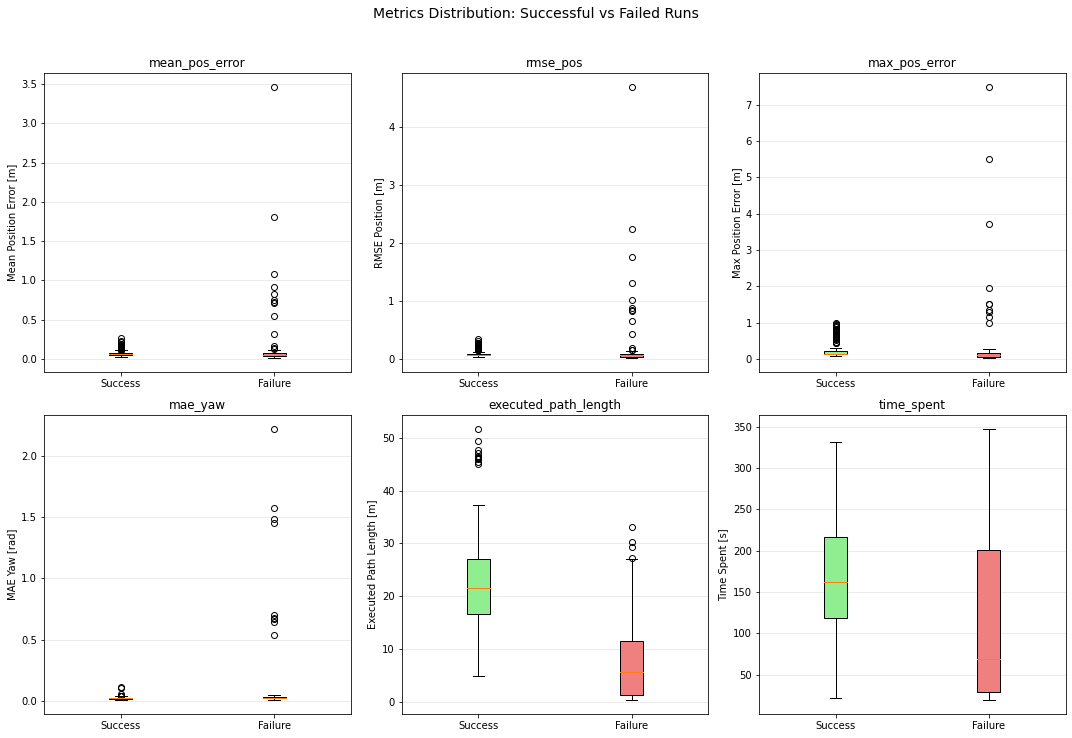

In [ ]:

# METRICS DISTRIBUTION BY RUN OUTCOME

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metric_cols = ['mean_pos_error', 'rmse_pos', 'max_pos_error', 'mae_yaw', 'executed_path_length', 'time_spent']
metric_labels = ['Mean Position Error [m]', 'RMSE Position [m]', 'Max Position Error [m]', 
                 'MAE Yaw [rad]', 'Executed Path Length [m]', 'Time Spent [s]']

for idx, (metric, label) in enumerate(zip(metric_cols, metric_labels)):
    ax = axes.flatten()[idx]
    
    success_data = analysis_df[analysis_df['failure_run'] == 0][metric].dropna()
    failure_data = analysis_df[analysis_df['failure_run'] == 1][metric].dropna()
    
    bp = ax.boxplot([success_data, failure_data], labels=['Success', 'Failure'], 
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_ylabel(label)
    ax.set_title(f'{metric}')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Metrics Distribution: Successful vs Failed Runs', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('images/metrics_distribution_outcome.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Summary: Anomaly Detection Pipeline Results

This section provides a comprehensive summary of the anomaly detection pipeline, including:
- Detection methodology for each anomaly type
- Single-source vs multi-source prediction capability
- Key predictive features identified

In [53]:

# FINAL SUMMARY TABLE

# Count runs and anomalies by scenario
scenario_summary = []
for scenario_group in dataset:
    if len(scenario_group) == 0:
        continue
    scenario_name = scenario_group[0].scenario
    total_runs = len(scenario_group)
    failed_runs = sum(1 for d in scenario_group if d.failure_run)
    total_anomalies = sum(len(d.anomalies) for d in scenario_group)
    unique_anomaly_types = set()
    for d in scenario_group:
        unique_anomaly_types.update(d.get_unique_anomalies())
    
    scenario_summary.append({
        'Scenario': scenario_name[:40] + '...' if len(scenario_name) > 40 else scenario_name,
        'Total Runs': total_runs,
        'Failed Runs': failed_runs,
        'Success Rate (%)': round(100 * (total_runs - failed_runs) / total_runs, 1),
        'Total Anomalies': total_anomalies,
        'Unique Anomaly Types': len(unique_anomaly_types)
    })

summary_df = pd.DataFrame(scenario_summary)
print("=" * 80)
print("SCENARIO-LEVEL SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

# Overall statistics
print("\n" + "=" * 80)
print("OVERALL PIPELINE STATISTICS")
print("=" * 80)
total_runs = sum(s['Total Runs'] for s in scenario_summary)
total_failed = sum(s['Failed Runs'] for s in scenario_summary)
total_anom = sum(s['Total Anomalies'] for s in scenario_summary)
print(f"Total runs analyzed: {total_runs}")
print(f"Total failed runs: {total_failed} ({100*total_failed/total_runs:.1f}%)")
print(f"Total anomalies detected: {total_anom}")
print(f"Average anomalies per run: {total_anom/total_runs:.2f}")

SCENARIO-LEVEL SUMMARY
                 Scenario  Total Runs  Failed Runs  Success Rate (%)  Total Anomalies  Unique Anomaly Types
  floorplan-failure-4s7-9           3            3               0.0                3                     1
 floorplan-failure-4f11-1           3            3               0.0                3                     1
  floorplan-failure-4s5-4           3            3               0.0                3                     1
 floorplan-failure-4s2-24           3            3               0.0                3                     1
 floorplan-failure-4s2-23           3            3               0.0                3                     1
  floorplan-failure-4s5-3           3            3               0.0                3                     1
 floorplan-failure-4f13-2           3            3               0.0                3                     1
 floorplan-failure-4s2-15           3            3               0.0                3                     1
hallw

In [54]:

# ANOMALY DETECTION METHODOLOGY SUMMARY

detection_methods = {
    'Anomaly Type': [
        'no_initiation', 'fatal_initialization', 'planner_failure', 'no_progress',
        'collision', 'stuck', 'goal_failure', 'time_outlier', 'position_error', 'navigation_performance'
    ],
    'Detection Method': [
        'Rule-based (Log)', 'Rule-based (Log)', 'Rule-based (Log)', 'Rule-based (Log)',
        'Rule-based (Log)', 'Rule-based (Log)', 'Rule-based (Log)', 
        'Statistical (MAD)', 'Statistical (3σ)', 'ML (Isolation Forest)'
    ],
    'Data Source': [
        'Logs (absence)', 'Logs (FATAL)', 'Logs (keyword)', 'Logs (keyword)',
        'Logs (keyword)', 'Logs (keyword)', 'Logs (keyword)',
        'Run duration', 'Pose CSV', 'Multiple metrics'
    ],
    'Single/Multi Source': [
        'Single', 'Single', 'Single', 'Single',
        'Single', 'Single', 'Single',
        'Single', 'Single', 'Multi'
    ],
    'Predictive Capability': [
        'Immediate failure', 'Immediate failure', 'Recoverable', 'Recoverable',
        'Warning signal', 'Warning signal', 'Terminal', 
        'Late indicator', 'Continuous', 'Holistic'
    ]
}

methods_df = pd.DataFrame(detection_methods)
print("\n" + "=" * 100)
print("ANOMALY DETECTION METHODOLOGY")
print("=" * 100)
print(methods_df.to_string(index=False))

print("\n" + "=" * 100)
print("KEY FINDINGS FOR EARLY PREDICTION")
print("=" * 100)
print("""
1. FATAL INDICATORS (Immediate failure):
   - 'no_initiation' and 'fatal_initialization' → Almost always result in run failure
   - These are single-source detectable from logs alone

2. WARNING SIGNALS (Predictive):
   - 'collision' → Often followed by 'stuck' → leads to 'no_progress'
   - Early position error spikes can predict later navigation failures
   - High early mean error correlates with eventual run failure

3. ACCUMULATING ANOMALIES:
   - 'planner_failure' and 'no_progress' tend to accumulate within problematic runs
   - Multiple occurrences increase likelihood of 'time_outlier' and 'goal_failure'

4. MULTI-SOURCE DETECTION:
   - 'navigation_performance' uses Isolation Forest on combined metrics
   - Captures runs that succeed but exhibit unusual behavior patterns
""")


ANOMALY DETECTION METHODOLOGY
          Anomaly Type      Detection Method      Data Source Single/Multi Source Predictive Capability
         no_initiation      Rule-based (Log)   Logs (absence)              Single     Immediate failure
  fatal_initialization      Rule-based (Log)     Logs (FATAL)              Single     Immediate failure
       planner_failure      Rule-based (Log)   Logs (keyword)              Single           Recoverable
           no_progress      Rule-based (Log)   Logs (keyword)              Single           Recoverable
             collision      Rule-based (Log)   Logs (keyword)              Single        Warning signal
                 stuck      Rule-based (Log)   Logs (keyword)              Single        Warning signal
          goal_failure      Rule-based (Log)   Logs (keyword)              Single              Terminal
          time_outlier     Statistical (MAD)     Run duration              Single        Late indicator
        position_error      Stati

In [55]:

# SAVE ALL EXISTING FIGURES TO IMAGES FOLDER

# Ensure images directory exists
os.makedirs('images', exist_ok=True)

print("Figures saved to images/ folder:")
print("  - correlation_metrics_anomalies.png")
print("  - early_prediction_analysis.png") 
print("  - anomaly_cooccurrence.png")
print("  - metrics_distribution_outcome.png")
print("\nNote: Previous figures (Localization_Error_Distribution.png, Anomalies_*.png, Anomaly_Timeline_*.png)")
print("should be saved by re-running the respective cells with plt.savefig() added.")

Figures saved to images/ folder:
  - correlation_metrics_anomalies.png
  - early_prediction_analysis.png
  - anomaly_cooccurrence.png
  - metrics_distribution_outcome.png

Note: Previous figures (Localization_Error_Distribution.png, Anomalies_*.png, Anomaly_Timeline_*.png)
should be saved by re-running the respective cells with plt.savefig() added.


## Conclusion

This notebook implements a complete **anomaly detection pipeline** for robot navigation data with the following components:

### Data Preprocessing
- **Missing data handling**: Runs without CSV files or logs are flagged and handled gracefully
- **Noisy data filtering**: Position error anomalies require 3 consecutive threshold violations to filter transient noise
- **Timestamp alignment**: Ground truth and estimated poses are interpolated to common timestamps

### Anomaly Detection Methods
| Method | Anomalies Detected |
|--------|-------------------|
| **Rule-based (Logs)** | no_initiation, fatal_initialization, planner_failure, no_progress, collision, stuck, goal_failure |
| **Statistical (3σ)** | position_error |
| **Statistical (MAD)** | time_outlier |
| **ML (Isolation Forest)** | navigation_performance |

### Key Findings for Early Prediction
1. **Early phase localization error** correlates significantly with eventual run failure
2. **Collision → Stuck → No Progress** forms a causal chain that can be predicted
3. **Accumulation of planner_failure or no_progress** anomalies predicts time_outlier and goal_failure
4. **Multi-metric Isolation Forest** captures runs with unusual behavior patterns even when they succeed

